# Paper-style figure reproduction (RTX6000)

This notebook reproduces the *script-equivalent* plots used in this folder (same outputs as `plot_*.py`) directly from the JSON outputs under `results/`.

It also writes the same intermediate CSV matrices under `results/`:
- `results/*_latency.csv` (HP p95 latency matrix)
- `results/*_{be,hp}_throughput.csv` (BE/HP throughput matrices)

Notes:
- The repo’s JSON latencies are typically reported in microseconds; we write the CSVs in **milliseconds** to match the plotting scripts’ axis labels.
- Run this notebook from this folder (where `results/` lives).

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import (
    MODELS_RTX6000_DEFAULT,
    LAT_US_TO_MS,
    build_paper_matrices_from_disk,
    load_json_maybe,
    parse_mean_matrix,
    parse_std_matrix,
    parse_mean_pair,
    parse_std_pair,
)

BASE = Path('.')
MODELS = MODELS_RTX6000_DEFAULT
RUNS = [0]
RESULTS_DIR = BASE / 'results'

In [4]:
# Build CSV matrices under results/ (same schema as gather_results.py)
mats = build_paper_matrices_from_disk(BASE, models=MODELS, runs=RUNS, latency_unit='ms')
print('Built matrices for:', sorted(mats.keys()))
print('CSV dir:', RESULTS_DIR.resolve())

method_order = ['Temporal', 'Streams', 'MPS', 'REEF', 'Orion', 'Ideal']
method2prefix = {
    'Temporal': 'temporal',
    'Streams': 'streams',
    'MPS': 'mps',
    'REEF': 'reef',
    'Orion': 'orion',
    'Ideal': 'ideal',
}

available_methods = []
for m in method_order:
    prefix = method2prefix[m]
    if (RESULTS_DIR / f'{prefix}_latency.csv').exists() and (RESULTS_DIR / f'{prefix}_be_throughput.csv').exists() and (RESULTS_DIR / f'{prefix}_hp_throughput.csv').exists():
        available_methods.append(m)
print('Available methods:', available_methods)

Built matrices for: ['ideal', 'mps', 'orion', 'reef', 'streams', 'temporal']
CSV dir: /home/cc/orion/rtx6000_results/inf_inf_updated/results
Available methods: ['Temporal', 'Streams', 'MPS', 'REEF', 'Orion', 'Ideal']


## Figure: total throughput (stacked BE+HP)
Reproduces the stacked-bar plot saved by `plot_throughput.py` as `inf_inf_poisson_total_throughput.png`.

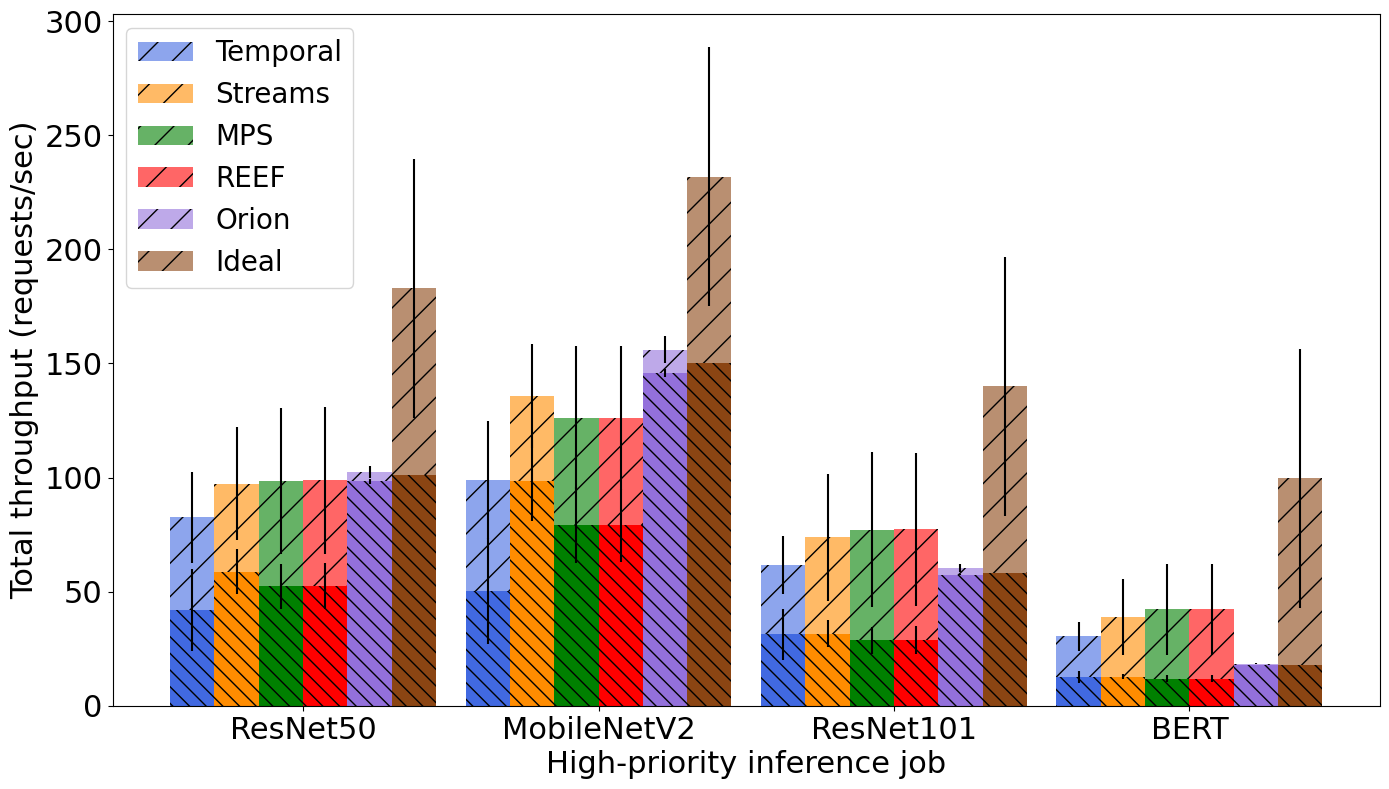

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_total_throughput.png


In [5]:
colors = ['royalblue', 'darkorange', 'green', 'red', 'mediumpurple', 'saddlebrown']
width = 0.15 if len(available_methods) >= 4 else 0.25

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(MODELS))

for method_id, method in enumerate(available_methods):
    prefix = method2prefix[method]
    be_csv = RESULTS_DIR / f'{prefix}_be_throughput.csv'
    hp_csv = RESULTS_DIR / f'{prefix}_hp_throughput.csv'
    be_mean, hp_mean = parse_mean_pair(be_csv, hp_csv, models=MODELS)
    be_std, hp_std = parse_std_pair(be_csv, hp_csv, models=MODELS)

    ax.bar(
        x + width * method_id, hp_mean.values, width, yerr=hp_std.values,
        align='edge', hatch='\\\\', color=colors[method_id % len(colors)]
    )
    ax.bar(
        x + width * method_id, be_mean.values, width, yerr=be_std.values,
        bottom=hp_mean.values, align='edge', hatch='/',
        color=colors[method_id % len(colors)], alpha=0.6, label=method
    )

x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=22)
plt.yticks(fontsize=22)
ax.set_ylabel('Total throughput (requests/sec)', fontsize=22)
ax.set_xlabel('High-priority inference job', fontsize=22)
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', ncol=1, fontsize=20)

out_path = BASE / 'inf_inf_poisson_total_throughput.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_path.resolve())

## Figure: HP p95 latency bars
Reproduces the multi-method HP latency comparison saved by `plot_latency.py` as `inf_inf_poisson_hp_latency.png`.

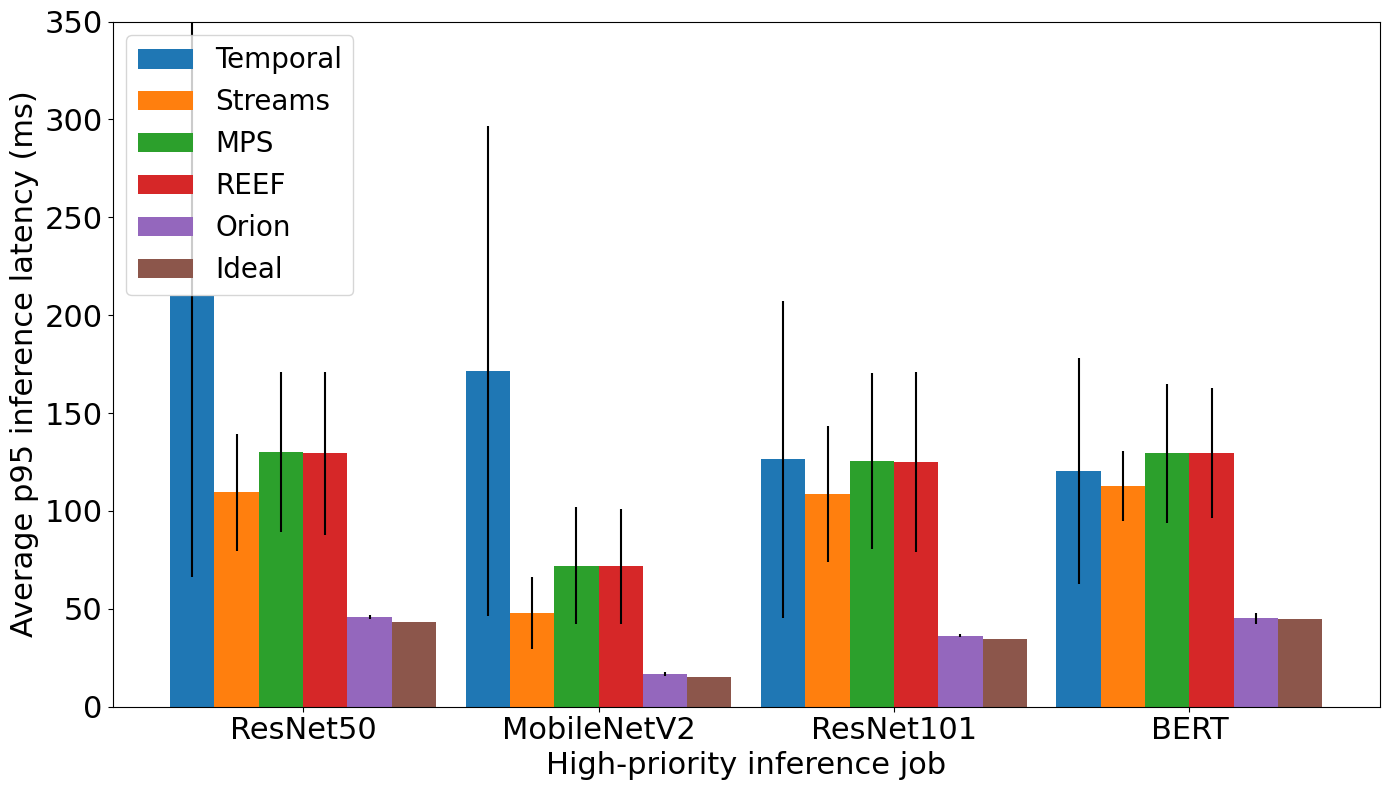

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_latency.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25

for method_id, method in enumerate(available_methods):
    prefix = method2prefix[method]
    lat_csv = RESULTS_DIR / f'{prefix}_latency.csv'
    lat_mean = parse_mean_matrix(lat_csv, models=MODELS)
    lat_std = parse_std_matrix(lat_csv, models=MODELS)
    ax.bar(
        x + width * method_id, lat_mean.values, width,
        yerr=lat_std.values, align='edge', label=method
    )

x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=22)
plt.yticks(fontsize=22)
ax.set_ylim(0, 350)
ax.set_ylabel('Average p95 inference latency (ms)', fontsize=22)
ax.set_xlabel('High-priority inference job', fontsize=22)
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', ncol=1, fontsize=20)

out_path = BASE / 'inf_inf_poisson_hp_latency.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_path.resolve())

## Script-equivalent comparison: MPS vs Ideal
These reproduce `plot_comparison.py` outputs:
- `results/mps_vs_ideal_latency.png`
- `results/mps_vs_ideal_throughput.png`
- `results/mps_slowdown_heatmap.png`

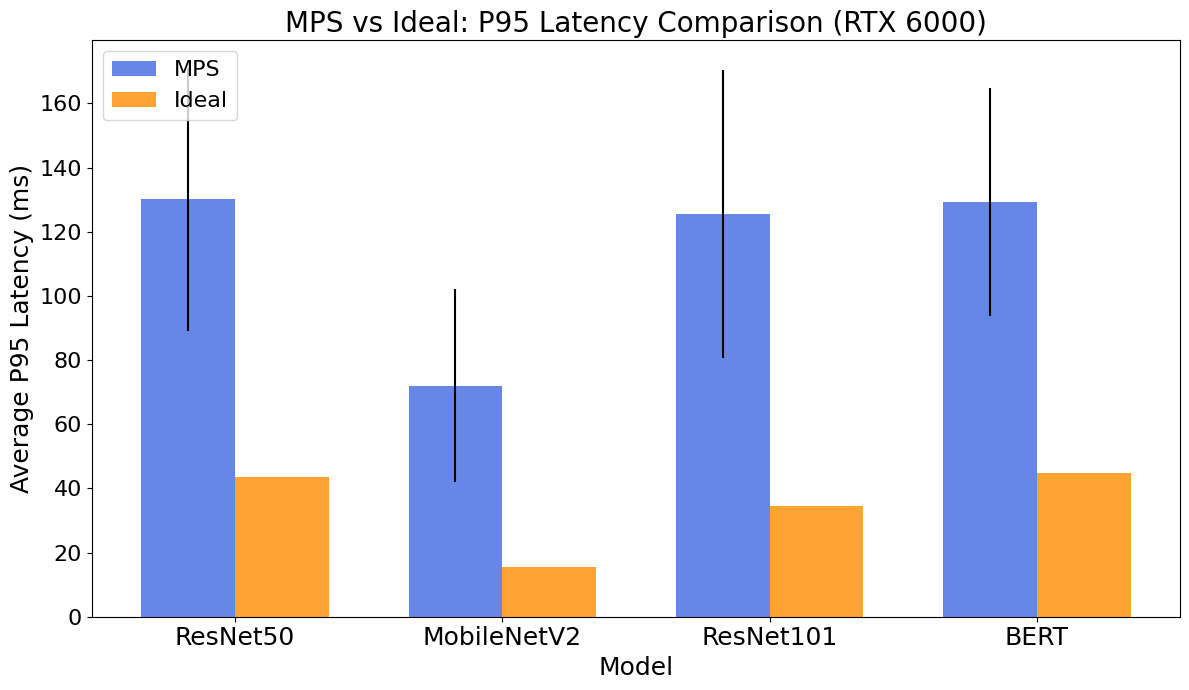

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_vs_ideal_latency.png


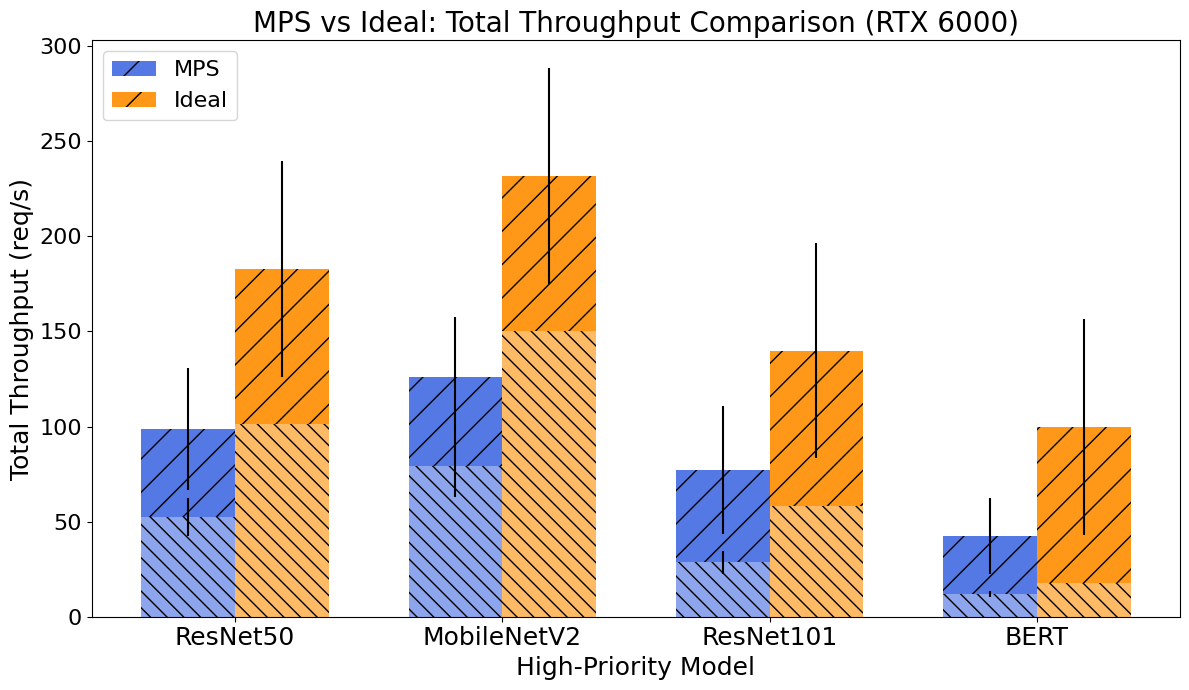

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_vs_ideal_throughput.png


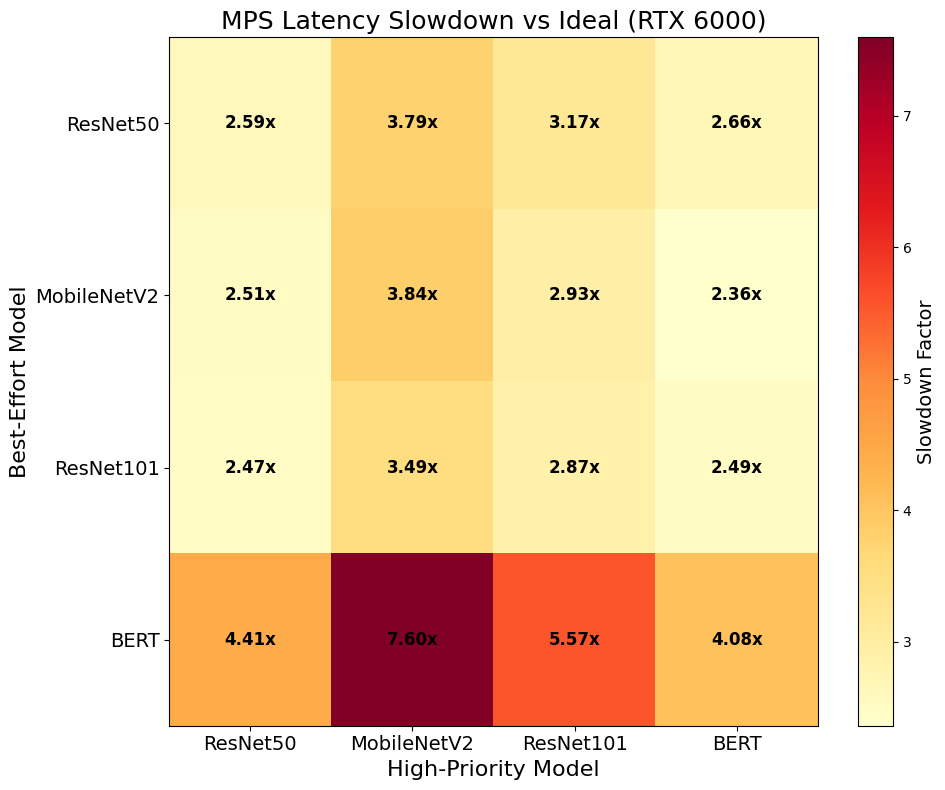

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_slowdown_heatmap.png


In [7]:
def _mean_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    out = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
    for be in MODELS:
        for hp in MODELS:
            out.at[be, hp] = float(str(df.at[be, hp]).split('/')[0])
    return out

# Latency comparison: MPS vs Ideal (bars)
colors2 = ['royalblue', 'darkorange']
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(MODELS))

mps_lat_mean = parse_mean_matrix(RESULTS_DIR / 'mps_latency.csv', models=MODELS)
mps_lat_std = parse_std_matrix(RESULTS_DIR / 'mps_latency.csv', models=MODELS)
ideal_lat_mean = parse_mean_matrix(RESULTS_DIR / 'ideal_latency.csv', models=MODELS)
ideal_lat_std = parse_std_matrix(RESULTS_DIR / 'ideal_latency.csv', models=MODELS)

ax.bar(x + width * 0, mps_lat_mean.values, width, label='MPS', yerr=mps_lat_std.values, align='edge', color=colors2[0], alpha=0.8)
ax.bar(x + width * 1, ideal_lat_mean.values, width, label='Ideal', yerr=ideal_lat_std.values, align='edge', color=colors2[1], alpha=0.8)

x_tick_positions = x + width
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=16)
ax.set_ylabel('Average P95 Latency (ms)', fontsize=18)
ax.set_xlabel('Model', fontsize=18)
ax.set_title('MPS vs Ideal: P95 Latency Comparison (RTX 6000)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()

out_lat = RESULTS_DIR / 'mps_vs_ideal_latency.png'
plt.savefig(out_lat, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_lat.resolve())

# Throughput comparison: MPS vs Ideal (stacked)
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(MODELS))
width = 0.35

mps_be_mean, mps_hp_mean = parse_mean_pair(RESULTS_DIR / 'mps_be_throughput.csv', RESULTS_DIR / 'mps_hp_throughput.csv', models=MODELS)
mps_be_std, mps_hp_std = parse_std_pair(RESULTS_DIR / 'mps_be_throughput.csv', RESULTS_DIR / 'mps_hp_throughput.csv', models=MODELS)
ideal_be_mean, ideal_hp_mean = parse_mean_pair(RESULTS_DIR / 'ideal_be_throughput.csv', RESULTS_DIR / 'ideal_hp_throughput.csv', models=MODELS)
ideal_be_std, ideal_hp_std = parse_std_pair(RESULTS_DIR / 'ideal_be_throughput.csv', RESULTS_DIR / 'ideal_hp_throughput.csv', models=MODELS)

ax.bar(x + width * 0, mps_hp_mean.values, width, yerr=mps_hp_std.values, align='edge', hatch='\\\\', color=colors2[0], alpha=0.6)
ax.bar(x + width * 0, mps_be_mean.values, width, label='MPS', yerr=mps_be_std.values, bottom=mps_hp_mean.values, align='edge', hatch='/', color=colors2[0], alpha=0.9)

ax.bar(x + width * 1, ideal_hp_mean.values, width, yerr=ideal_hp_std.values, align='edge', hatch='\\\\', color=colors2[1], alpha=0.6)
ax.bar(x + width * 1, ideal_be_mean.values, width, label='Ideal', yerr=ideal_be_std.values, bottom=ideal_hp_mean.values, align='edge', hatch='/', color=colors2[1], alpha=0.9)

x_tick_positions = x + width
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=16)
ax.set_ylabel('Total Throughput (req/s)', fontsize=18)
ax.set_xlabel('High-Priority Model', fontsize=18)
ax.set_title('MPS vs Ideal: Total Throughput Comparison (RTX 6000)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()

out_thr = RESULTS_DIR / 'mps_vs_ideal_throughput.png'
plt.savefig(out_thr, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_thr.resolve())

# Slowdown heatmap: MPS latency / Ideal latency
df_mps_lat = _mean_df(RESULTS_DIR / 'mps_latency.csv')
df_ideal_lat = _mean_df(RESULTS_DIR / 'ideal_latency.csv')
slowdown = (df_mps_lat / df_ideal_lat).replace([np.inf, -np.inf], np.nan).fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(slowdown.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(np.arange(len(MODELS)))
ax.set_yticks(np.arange(len(MODELS)))
ax.set_xticklabels(MODELS, fontsize=14)
ax.set_yticklabels(MODELS, fontsize=14)
ax.set_xlabel('High-Priority Model', fontsize=16)
ax.set_ylabel('Best-Effort Model', fontsize=16)
ax.set_title('MPS Latency Slowdown vs Ideal (RTX 6000)', fontsize=18)

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        ax.text(j, i, f'{slowdown.iloc[i, j]:.2f}x', ha='center', va='center', color='black', fontsize=12, weight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Slowdown Factor', fontsize=14)
plt.tight_layout()
out_hm = RESULTS_DIR / 'mps_slowdown_heatmap.png'
plt.savefig(out_hm, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_hm.resolve())

## Extra: average HP p99 latency and HP throughput
Averaged across BE models for each HP model (matching the averaging style of the paper-style p95 plot).

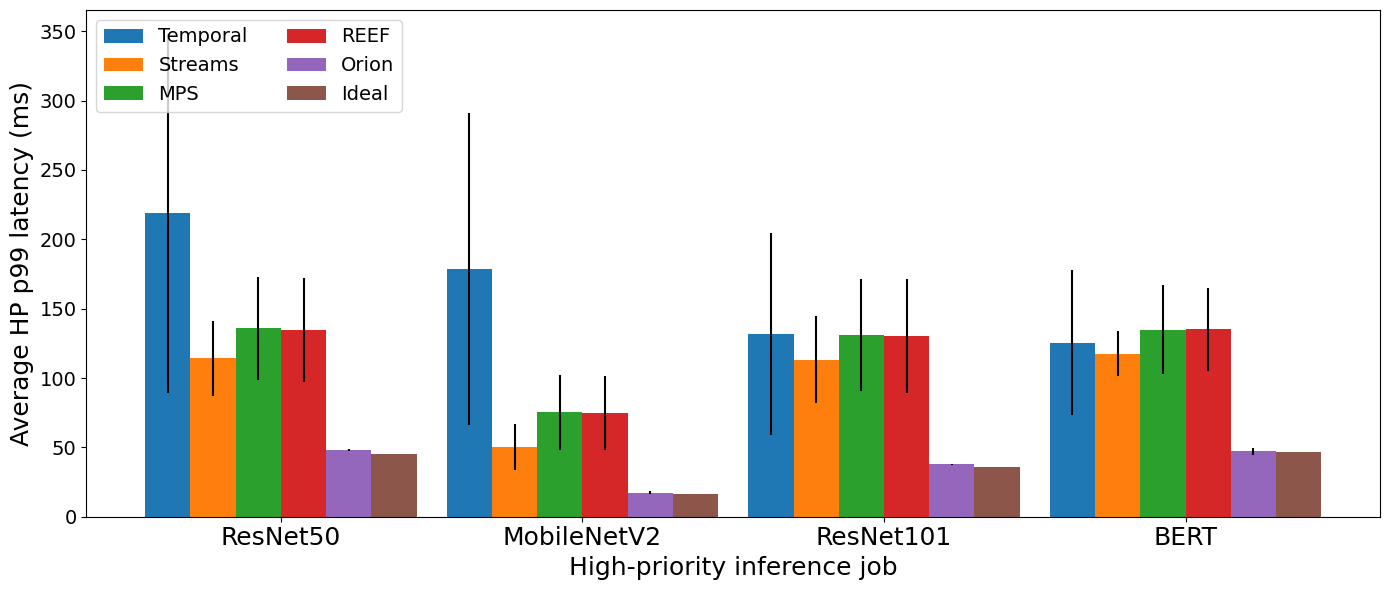

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_p99_latency.png


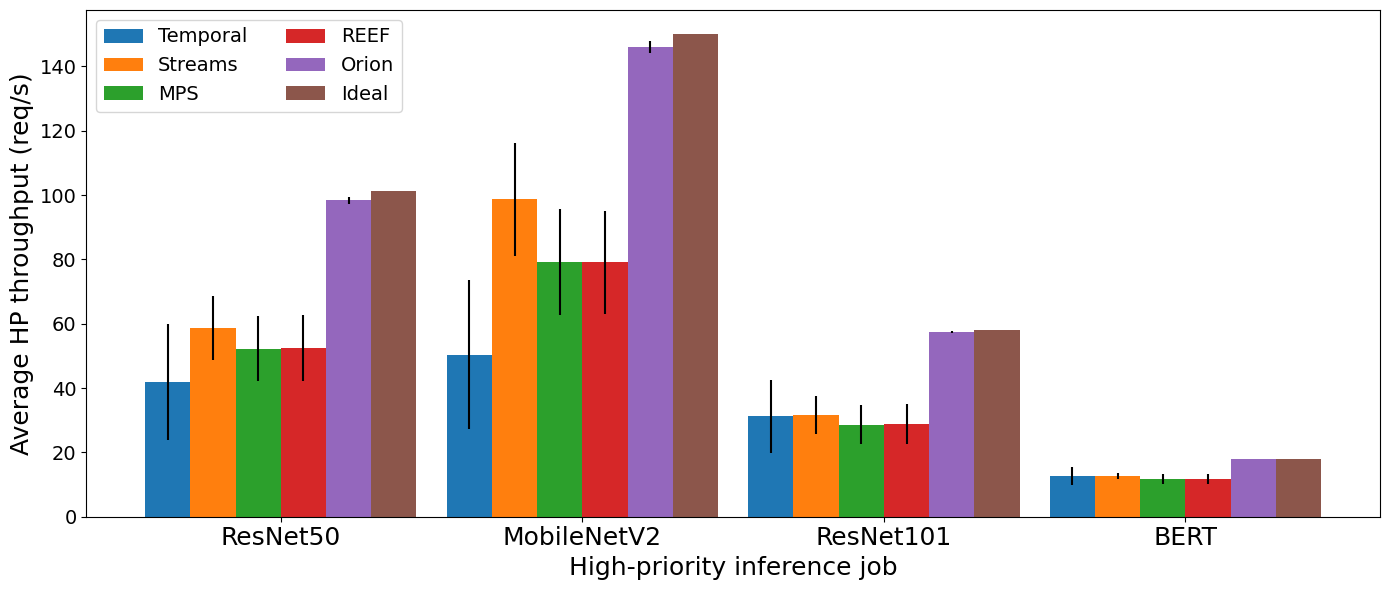

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_throughput.png


In [8]:
def _avg_hp_p99_latency_ms(method: str) -> tuple[np.ndarray, np.ndarray]:
    prefix = method2prefix[method]
    means, stds = [], []
    for hp in MODELS:
        vals = []
        if prefix in {'mps', 'streams'}:
            for be in MODELS:
                for run in RUNS:
                    p = RESULTS_DIR / prefix / f'{hp}_{be}_{run}.json'
                    d = load_json_maybe(p)
                    if not d or d.get('p99-latency-0') is None:
                        continue
                    vals.append(float(d['p99-latency-0']) * LAT_US_TO_MS)
        elif prefix == 'ideal':
            for p in (RESULTS_DIR / 'ideal').glob(f'{hp}_*_hp.json'):
                d = load_json_maybe(p)
                if not d or d.get('p99_latency') is None:
                    continue
                vals.append(float(d['p99_latency']) * LAT_US_TO_MS)
        else:
            for be in MODELS:
                for run in RUNS:
                    p = RESULTS_DIR / prefix / f'{be}_{hp}_{run}_hp.json'
                    d = load_json_maybe(p)
                    if not d or d.get('p99_latency') is None:
                        continue
                    vals.append(float(d['p99_latency']) * LAT_US_TO_MS)

        arr = np.asarray(vals, dtype=float)
        means.append(float(arr.mean()) if len(arr) else float('nan'))
        stds.append(float(arr.std()) if len(arr) else float('nan'))
    return np.asarray(means), np.asarray(stds)


def _avg_hp_throughput(method: str) -> tuple[np.ndarray, np.ndarray]:
    prefix = method2prefix[method]
    csv_hp = RESULTS_DIR / f'{prefix}_hp_throughput.csv'
    df = pd.read_csv(csv_hp)
    df = df.drop(df.columns[0], axis=1)
    df.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df.at[r, c] = float(str(df.at[r, c]).split('/')[0])
    return df.mean().values, df.std().values


# --- Plot 1: average HP p99 latency (ms) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25
for method_id, method in enumerate(available_methods):
    mu, sd = _avg_hp_p99_latency_ms(method)
    ax.bar(x + width * method_id, mu, width, yerr=sd, align='edge', label=method)
x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=14)
ax.set_ylabel('Average HP p99 latency (ms)', fontsize=18)
ax.set_xlabel('High-priority inference job', fontsize=18)
plt.tight_layout()
plt.legend(loc='upper left', ncol=2, fontsize=14)
out_p99 = BASE / 'inf_inf_poisson_hp_p99_latency.png'
plt.savefig(out_p99, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_p99.resolve())

# --- Plot 2: average HP throughput (req/s) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25
for method_id, method in enumerate(available_methods):
    mu, sd = _avg_hp_throughput(method)
    ax.bar(x + width * method_id, mu, width, yerr=sd, align='edge', label=method)
x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=14)
ax.set_ylabel('Average HP throughput (req/s)', fontsize=18)
ax.set_xlabel('High-priority inference job', fontsize=18)
plt.tight_layout()
plt.legend(loc='upper left', ncol=2, fontsize=14)
out_hp_thr = BASE / 'inf_inf_poisson_hp_throughput.png'
plt.savefig(out_hp_thr, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_hp_thr.resolve())